In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dmtandsully/indian-grain-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/dmtandsully/indian-grain-classification


In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
import os

In [3]:
train_dir=os.path.join(path,'TRAIN DATA')
val_dir=os.path.join(path,'VALIDATION DATA')
test_dir=os.path.join(path,'TEST DATA')
import random

In [32]:
def view_random_image(target_dir):
    # random_class=random.choice(os.listdir(target_dir))
    random_class='chole'
    random_image=random.choice(os.listdir(os.path.join(target_dir,random_class)))
    random_image_path=os.path.join(target_dir,random_class,random_image)
    img=mpimg.imread(random_image_path)
    plt.figure(figsize=(10,7))
    plt.title(f"Class :{random_class} Image Shape :{img.shape}")
    plt.axis(False)
    plt.imshow(img)

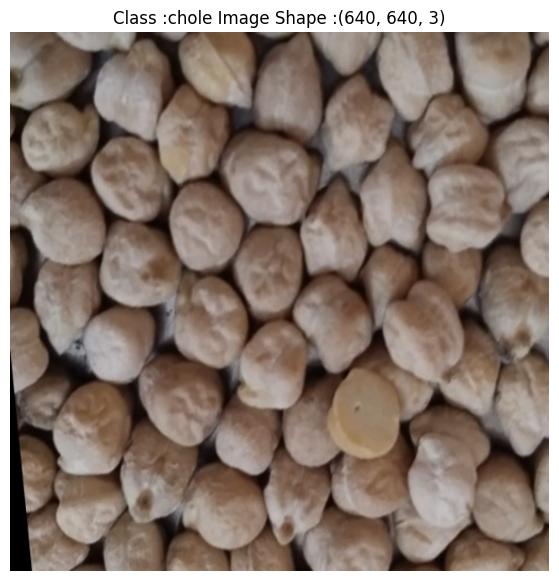

In [36]:
view_random_image(train_dir)

In [6]:
train_data=tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                               label_mode='categorical',
                                                               image_size=(224,224),
                                                               batch_size=32,
                                                               shuffle=True,
                                                               seed=42)
val_data=tf.keras.preprocessing.image_dataset_from_directory(val_dir,
                                                               label_mode='categorical',
                                                               image_size=(224,224),
                                                               batch_size=32,
                                                               shuffle=True,
                                                               seed=42)
test_data=tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                               label_mode='categorical',
                                                               image_size=(224,224),
                                                               batch_size=32,
                                                               shuffle=True,
                                                               seed=42)
                                                               
                                                               

Found 5250 files belonging to 10 classes.


I0000 00:00:1784523382.513740      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784523382.516897      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1120 files belonging to 10 classes.
Found 1130 files belonging to 10 classes.


In [12]:
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomHeight(0.2),
    tf.keras.layers.RandomWidth(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

In [13]:
base_model=tf.keras.applications.EfficientNetB0(include_top=False)
inputs=tf.keras.layers.Input(shape=(224,224,3),name='input_layer')
x=data_augmentation(inputs)
x=base_model(x)
x=tf.keras.layers.GlobalAveragePooling2D(name='Global_Average_Pooling_Layer')(x)
x=tf.keras.layers.Dropout(0.3,name='Dropout_Layer')(x)
outputs=tf.keras.layers.Dense(10,activation='softmax',name='Output_Layer')(x)

model=tf.keras.Model(inputs,outputs)

model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

early_stopping=tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                patience=3,
                                                restore_best_weights=True)

In [14]:
history=model.fit(train_data,
                  epochs=10,
                  validation_data=val_data,
                  callbacks=[early_stopping])


Epoch 1/10


E0000 00:00:1784524326.125978      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


165/165 ━━━━━━━━━━━━━━━━━━━━ 118s 484ms/step - accuracy: 0.9055 - loss: 0.3060 - val_accuracy: 0.7848 - val_loss: 1.4104
Epoch 2/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 77s 468ms/step - accuracy: 0.9579 - loss: 0.1438 - val_accuracy: 0.7795 - val_loss: 1.0589
Epoch 3/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 78s 473ms/step - accuracy: 0.9659 - loss: 0.1024 - val_accuracy: 0.8518 - val_loss: 0.7333
Epoch 4/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 77s 466ms/step - accuracy: 0.9731 - loss: 0.0810 - val_accuracy: 0.8446 - val_loss: 1.1023
Epoch 5/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 78s 469ms/step - accuracy: 0.9747 - loss: 0.0820 - val_accuracy: 0.7893 - val_loss: 0.9670
Epoch 6/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 77s 469ms/step - accuracy: 0.9766 - loss: 0.0767 - val_accuracy: 0.8062 - val_loss: 0.7153
Epoch 7/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 76s 462ms/step - accuracy: 0.9739 - loss: 0.0825 - val_accuracy: 0.8250 - val_loss: 1.8720
Epoch 8/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 77s 464ms/step - accuracy: 0.9859 - loss: 0.0482 - va

In [15]:
def plot_loss_accuracy(history):
    loss=history.history['loss']
    val_loss=history.history['val_loss']
    accuracy=history.history['accuracy']
    val_accuracy=history.history['val_accuracy']
    epochs=range(len(loss))
    plt.figure(figsize=(10,7))
    plt.subplot(1,2,1)
    plt.title('Training and Validation Loss')
    plt.plot(epochs,loss,label='Training Loss')
    plt.plot(epochs,val_loss,label='Validation Loss')
    plt.legend()
    plt.subplot(1,2,2)
    plt.title('Training and Validation Accuracy')
    plt.plot(epochs,accuracy,label='Training Accuracy')
    plt.plot(epochs,val_accuracy,label='Validation Accuracy')
    plt.legend()
    plt.show()

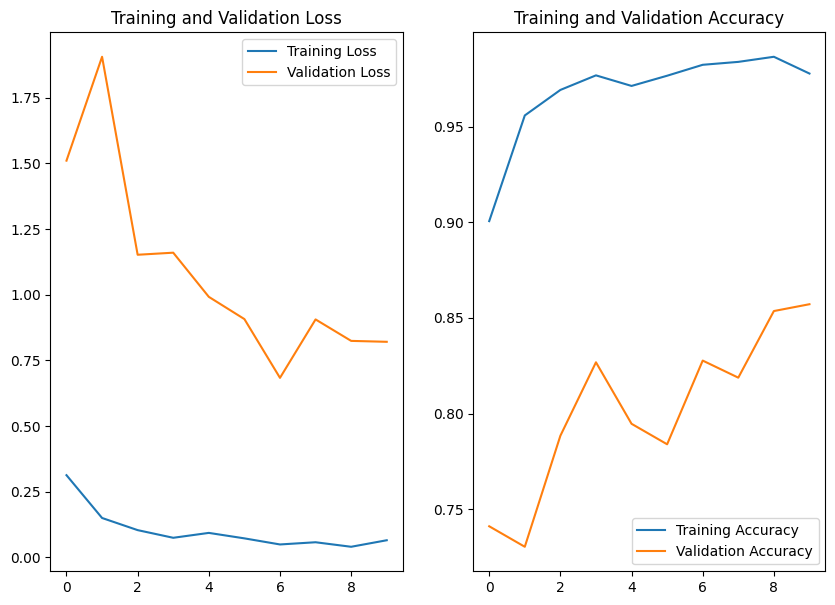

In [11]:
plot_loss_accuracy(history)

In [16]:
results=model.evaluate(test_data)
print(f"Test Loss :{results[0]} Test Accuracy :{results[1]*100}%")


36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 576ms/step - accuracy: 0.8681 - loss: 0.5096
Test Loss :0.5096056461334229 Test Accuracy :86.81415915489197%


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
import numpy as np
test_data_unshuffled = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    label_mode='categorical',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False  
)

y_pred = model.predict(test_data_unshuffled)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true_batches = [labels.numpy() for _, labels in test_data_unshuffled]
y_true = np.argmax(np.concatenate(y_true_batches, axis=0), axis=1)

# 4. Print report
print(classification_report(y_true, y_pred_classes))

Found 1130 files belonging to 10 classes.
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 445ms/step
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       113
           1       0.46      1.00      0.63       113
           2       1.00      0.78      0.88       113
           3       0.94      0.91      0.93       113
           4       1.00      1.00      1.00       113
           5       1.00      1.00      1.00       113
           6       1.00      0.02      0.03       113
           7       1.00      1.00      1.00       113
           8       0.98      1.00      0.99       113
           9       1.00      0.99      1.00       113

    accuracy                           0.87      1130
   macro avg       0.93      0.87      0.84      1130
weighted avg       0.93      0.87      0.84      1130



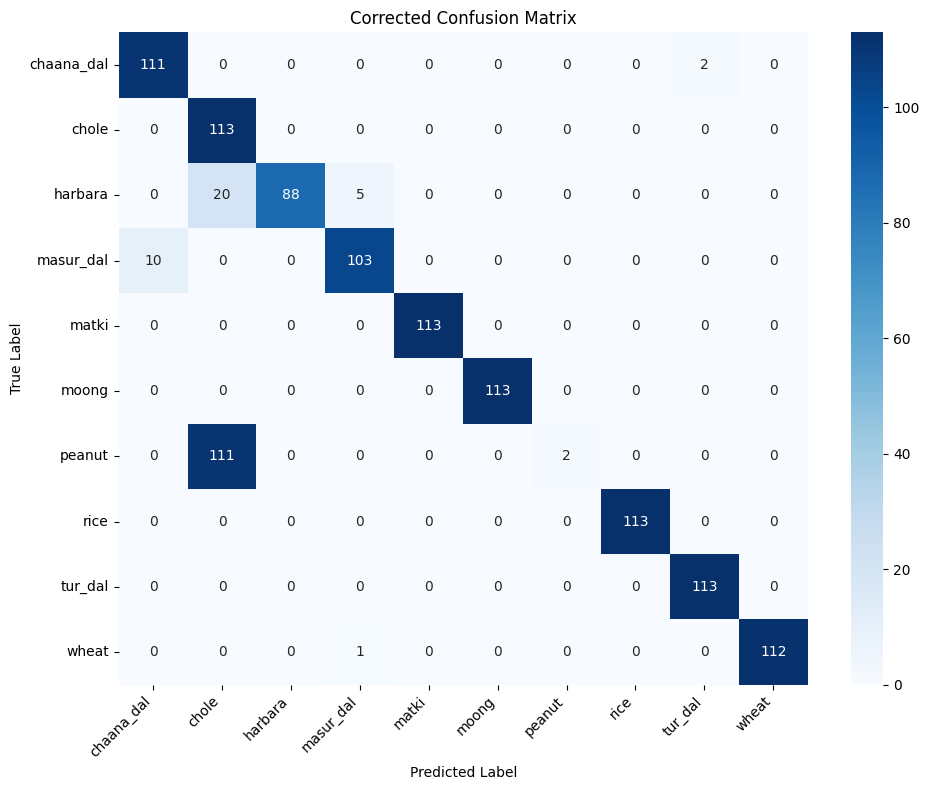

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Ensure class names match the exact alphabetical order used by Keras
class_names = sorted(test_data_unshuffled.class_names)

# 2. Compute matrix
cm = confusion_matrix(y_true, y_pred_classes)

# 3. Plot with explicit label matching
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Corrected Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()